In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
np.random.seed(42)
df = sns.load_dataset('tips')
print('Loaded tips dataset:',df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
print(df.dtypes)
numerical = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical : ',numerical)
print('Categorical : ',categorical)

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical :  ['total_bill', 'tip', 'size']
Categorical :  ['sex', 'smoker', 'day', 'time']


In [ ]:
print('Mean total_bill: ',round(df['total_bill'].mean(),2))
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill:  19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [ ]:
numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)
print("Mean of a numerical column (tip): ",df['tip'].mean())
print("Value counts of a categorical column (sex): ",df['sex'].value_counts())


Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']
Mean of a numerical column (tip):  2.99827868852459
Value counts of a categorical column (sex):  sex
Male      157
Female     87
Name: count, dtype: int64


In [ ]:
col = df['total_bill']
print('Mean :',round(col.mean(),2))
print('Median :',round(col.median(),2))
print('Mode :',round(col.mode()[0],2))

Mean : 19.79
Median : 17.8
Mode : 13.42


mean > median ? True -> right-skewed


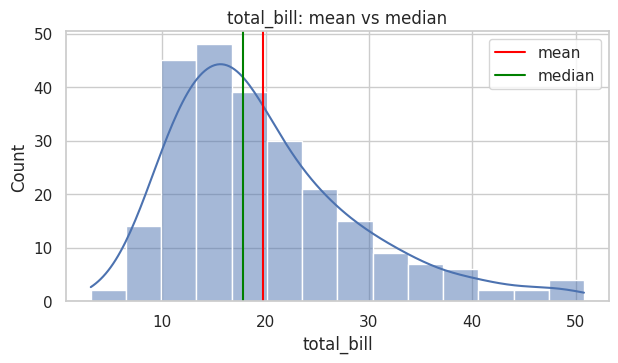

In [ ]:
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')
plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

Mean :  2.99827868852459
Median :  2.9
Mode :  2.0
mean > median ? True -> right-skewed


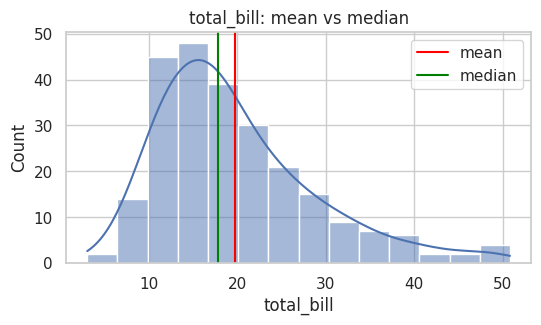

In [ ]:
tip = df['tip']
print("Mean : ",tip.mean())
print("Median : ",tip.median())
print("Mode : ",tip.mode()[0])
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')
plt.figure(figsize=(6, 3))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend();
plt.title('total_bill: mean vs median');
plt.show()

In [ ]:
col = df['total_bill']
print('Range : ',round(col.max()-col.min(),2))
print('Var : ',round(col.var(),2))
print('Std : ',round(col.std(),2))

Range :  47.74
Var :  79.25
Std :  8.9


In [ ]:
q1,q3 = col.quantile(0.25),col.quantile(0.75)
iqr = q3-q1
print('Q1 (25%):',round(q1,2))
print('Q3 (75%):',round(q3,2))
print('IQR :',round(iqr,2),'-> spread of the middle 50% (robust to outliers)')

Q1 (25%): 13.35
Q3 (75%): 24.13
IQR : 10.78 -> spread of the middle 50% (robust to outliers)


In [ ]:
tip = df['tip']
print("Range :",round(tip.max()-tip.min(),2))
print("Var :",round(tip.var(),2))
print("Std :",round(tip.std(),2))
Q1 = tip.quantile(0.25)
Q3 = tip.quantile(0.75)
IQR = Q3 - Q1
print("Q1: ",Q1)
print("Q3: ",Q3)
print("IQR: ",IQR)
print('IQR :',round(IQR,2),'-> spread of the middle 50% (robust to outliers)')

Range : 9.0
Var : 1.91
Std : 1.38
Q1:  2.0
Q3:  3.5625
IQR:  1.5625
IQR : 1.56 -> spread of the middle 50% (robust to outliers)


In [ ]:
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)
print('\nSkewness:', round(col.skew(), 3))

min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


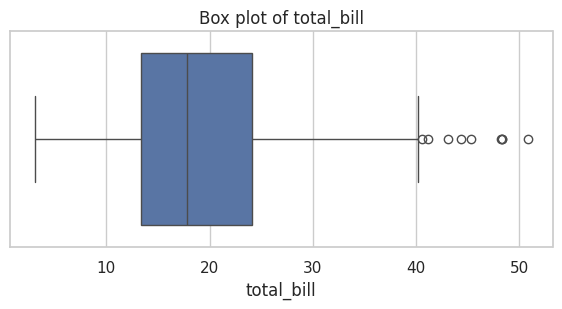

In [ ]:
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()

min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64

Skewness: 1.465


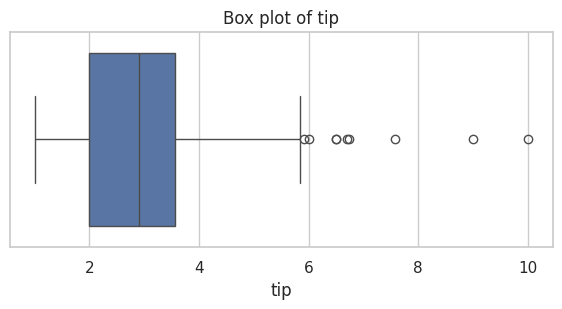

In [ ]:
tip = df['tip']
five = tip.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)
print('\nSkewness:', round(tip.skew(), 3))
# Positive skewness → right-skewed (leans to the right)
# Negative skewness → left-skewed (leans to the left)
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['tip'])
plt.title('Box plot of tip'); plt.show()

In [ ]:
corr = df.corr(numeric_only=True)
print(corr.round(2))
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


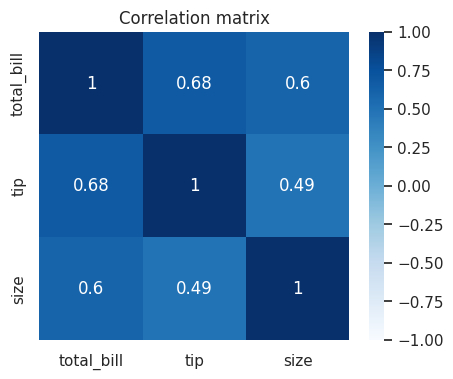

In [ ]:
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()

In [ ]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [ ]:
corr_matrix = df.corr(numeric_only=True).round(2)
corr_matrix

,total_bill,tip,size
total_bill,1.00,0.68,0.60
tip,0.68,1.00,0.49
size,0.60,0.49,1.00


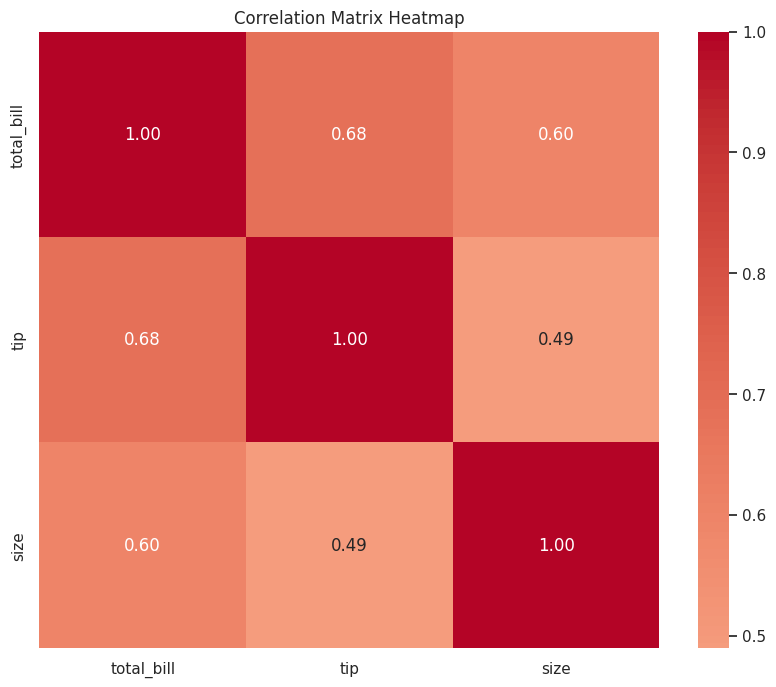

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:
df.describe()
#Insight 1: The descriptive statistics show the central tendency and spread
# of the numerical variables through measures such as mean, std, min, and max.

# Insight 2: The correlation matrix shows the strength and direction of
# linear relationships between the numerical variables.

# Insight 3: Variables with correlation values close to +1 or -1 have
# stronger linear relationships, while values close to 0 indicate weaker
# linear relationships.

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000
